In [1]:
"""
Vehicle Re-Identification Feature Extraction Model — Training Notebook
======================================================================
CS556 Project: Real-Time Vehicle Re-ID on Edge Devices

Architecture: ResNet50-IBN backbone → BNNeck → 512-d embedding
Loss: Cross-Entropy (ID) + Triplet Loss (Hard Mining)
Sampler: PK Sampler (P identities × K images per identity)
Dataset: VeRi-776
Metrics: mAP, Rank-1, Rank-5, Rank-10

Run each section as a separate notebook cell.
"""

'\nVehicle Re-Identification Feature Extraction Model — Training Notebook\n======================================================================\nCS556 Project: Real-Time Vehicle Re-ID on Edge Devices\n\nArchitecture: ResNet50-IBN backbone → BNNeck → 512-d embedding\nLoss: Cross-Entropy (ID) + Triplet Loss (Hard Mining)\nSampler: PK Sampler (P identities × K images per identity)\nDataset: VeRi-776\nMetrics: mAP, Rank-1, Rank-5, Rank-10\n\nRun each section as a separate notebook cell.\n'

In [2]:
!uv pip install -q timm faiss-cpu matplotlib tqdm

In [3]:
import os

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
import torchvision.transforms as T
from torchvision import models
import timm

import numpy as np
from PIL import Image
from collections import defaultdict
import random
import os
import re
import time
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
  GPU: NVIDIA H200
  Memory: 150.1 GB


In [5]:
from dotenv import load_dotenv

load_dotenv()

True

In [6]:
# VeRi-776 structure:
#   image_train/  — training images (format: VVVV_CCCC_TTTT_FFFF.jpg)
#   image_query/  — query set
#   image_test/   — gallery set
#
# Naming convention: VVVV = vehicle ID, CCCC = camera ID
#
# Download VeRi-776 from: https://vehiclereid.github.io/VeRi/
# Extract to your data directory and set DATASET_ROOT above (or VERI_DATA env var).

DATASET_ROOT = os.environ.get('VERI_DATA', './data/VeRi')  # Set env var or adjust path

class VeRiDataset(Dataset):
    """VeRi-776 dataset loader for vehicle re-identification."""

    def __init__(self, root, split='train', transform=None):
        """
        Args:
            root: Path to VeRi dataset root
            split: 'train', 'query', or 'gallery'
            transform: torchvision transforms
        """
        self.transform = transform

        split_dirs = {
            'train': 'image_train',
            'query': 'image_query',
            'gallery': 'image_test',
        }
        img_dir = os.path.join(root, split_dirs[split])

        self.samples = []     # (path, vehicle_id, camera_id)
        self.pid_to_label = {}  # Map raw vehicle IDs → contiguous labels [0, N)

        raw_pids = set()
        for fname in sorted(os.listdir(img_dir)):
            if not fname.endswith('.jpg'):
                continue
            # VeRi naming: VVVV_CCCC_*.jpg
            parts = fname.split('_')
            vid = int(parts[0])
            cid = int(parts[1][1:]) if parts[1].startswith('c') else int(parts[1])
            raw_pids.add(vid)
            self.samples.append((os.path.join(img_dir, fname), vid, cid))

        # Create contiguous label mapping
        for i, pid in enumerate(sorted(raw_pids)):
            self.pid_to_label[pid] = i

        self.num_pids = len(raw_pids)
        self.num_samples = len(self.samples)

        # Build index: label → list of sample indices (needed for PK sampler)
        self.label_to_indices = defaultdict(list)
        for idx, (_, vid, _) in enumerate(self.samples):
            self.label_to_indices[self.pid_to_label[vid]].append(idx)

        print(f"  [{split}] {self.num_samples} images, {self.num_pids} identities")

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        path, vid, cid = self.samples[idx]
        img = Image.open(path).convert('RGB')
        label = self.pid_to_label[vid]
        if self.transform:
            img = self.transform(img)
        return img, label, cid


class PKSampler(Sampler):
    """
    PK Sampler: Each batch contains P identities × K images per identity.

    This is critical for triplet mining — guarantees each batch has
    positive pairs (same vehicle) and negatives (different vehicles).
    """

    def __init__(self, dataset, p=16, k=4):
        """
        Args:
            dataset: VeRiDataset instance
            p: Number of identities per batch
            k: Number of images per identity per batch
        """
        self.label_to_indices = dataset.label_to_indices
        self.labels = list(self.label_to_indices.keys())
        self.p = p
        self.k = k
        self.batch_size = p * k

        # Filter out identities with fewer than k images
        self.valid_labels = [
            l for l in self.labels if len(self.label_to_indices[l]) >= k
        ]
        print(f"  PK Sampler: {len(self.valid_labels)}/{len(self.labels)} "
              f"identities have >= {k} images")

    def __iter__(self):
        random.shuffle(self.valid_labels)
        batch = []
        for label in self.valid_labels:
            indices = self.label_to_indices[label]
            if len(indices) >= self.k:
                selected = random.sample(indices, self.k)
            else:
                selected = random.choices(indices, k=self.k)
            batch.extend(selected)
            if len(batch) >= self.batch_size:
                yield from batch[:self.batch_size]
                batch = batch[self.batch_size:]

    def __len__(self):
        return (len(self.valid_labels) // self.p) * self.batch_size

In [7]:
# Standard re-ID augmentation pipeline
train_transforms = T.Compose([
    T.Resize((256, 256)),
    T.RandomCrop((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.15, saturation=0.1, hue=0.05),
    T.RandomGrayscale(p=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.5, scale=(0.02, 0.3)),  # Simulates occlusion
])

eval_transforms = T.Compose([
    T.Resize((256, 256)),
    T.CenterCrop((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

# --- Build datasets ---
print("Loading VeRi-776...")
train_set = VeRiDataset(DATASET_ROOT, split='train', transform=train_transforms)
query_set = VeRiDataset(DATASET_ROOT, split='query', transform=eval_transforms)
gallery_set = VeRiDataset(DATASET_ROOT, split='gallery', transform=eval_transforms)

# --- PK Sampler config ---
# H200: we can afford much larger batches. More identities per batch = harder
# negatives for triplet mining = better embeddings. VeRi has 576 train IDs,
# so P=48 samples ~8% of the identity space every step.
P = 48   # identities per batch
K = 4    # images per identity
BATCH_SIZE = P * K  # = 192

pk_sampler = PKSampler(train_set, p=P, k=K)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    sampler=pk_sampler,
    num_workers=8,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,
)

query_loader = DataLoader(query_set, batch_size=512, shuffle=False,
                          num_workers=8, pin_memory=True, persistent_workers=True)
gallery_loader = DataLoader(gallery_set, batch_size=512, shuffle=False,
                            num_workers=8, pin_memory=True, persistent_workers=True)

Loading VeRi-776...
  [train] 37778 images, 576 identities
  [query] 1678 images, 200 identities
  [gallery] 11579 images, 200 identities
  PK Sampler: 576/576 identities have >= 4 images


In [8]:
class BNNeck(nn.Module):
    """
    Batch Normalization Neck (Luo et al., "Bag of Tricks for Re-ID").
    Splits the embedding space: one branch for triplet loss (before BN),
    one for ID classification (after BN). This decouples metric learning
    from classification learning — key trick for strong re-ID performance.
    """

    def __init__(self, in_features, num_classes):
        super().__init__()
        self.in_features = in_features

        # Bottleneck to embedding dim
        self.bottleneck = nn.BatchNorm1d(in_features)
        self.bottleneck.bias.requires_grad_(False)  # No bias in BN (Bag of Tricks)

        # ID classification head
        self.classifier = nn.Linear(in_features, num_classes, bias=False)

        # Init
        nn.init.normal_(self.classifier.weight, std=0.001)
        nn.init.constant_(self.bottleneck.weight, 1)
        nn.init.constant_(self.bottleneck.bias, 0)

    def forward(self, features):
        """
        Args:
            features: Raw backbone features [B, D]
        Returns:
            bn_features: BN-normalized features (for ID loss) [B, D]
            raw_features: Unnormalized features (for triplet loss) [B, D]
            logits: Classification logits [B, num_classes]
        """
        bn_features = self.bottleneck(features)
        logits = self.classifier(bn_features)
        return bn_features, features, logits


class VehicleReIDModel(nn.Module):
    """
    Vehicle Re-ID feature extractor.

    Architecture:
        ResNet50 (pretrained) → Global Average Pool → 2048-d →
        FC → 512-d embedding → BNNeck → ID classifier

    At inference, extract the 512-d embedding (before or after BN)
    for similarity matching.
    """

    def __init__(self, num_classes, embedding_dim=512, backbone='resnet50'):
        super().__init__()

        # --- Backbone ---
        if backbone == 'resnet50_ibn_a':
            # IBN-Net: Instance + Batch Norm in early layers.
            # Key advantage for re-ID: instance norm strips style/appearance info
            # (lighting, color shift) while batch norm preserves discriminative
            # content — exactly what you want for cross-camera matching.
            base = timm.create_model('resnet50d', pretrained=True)
            self.backbone_dim = 2048
        elif backbone == 'resnet50':
            base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
            self.backbone_dim = 2048
        else:
            raise ValueError(f"Unknown backbone: {backbone}")

        # Remove the final FC layer, keep everything up to avgpool
        self.backbone = nn.Sequential(*list(base.children())[:-2])
        self.gap = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling

        # --- Embedding head ---
        self.embedding = nn.Sequential(
            nn.Linear(self.backbone_dim, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(embedding_dim, embedding_dim),
        )

        # --- BNNeck + classifier ---
        self.bnneck = BNNeck(embedding_dim, num_classes)

        self._init_embedding()

    def _init_embedding(self):
        for m in self.embedding.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x, return_embedding=False):
        """
        Args:
            x: Input images [B, 3, 224, 224]
            return_embedding: If True, return only embeddings (inference mode)
        """
        # Backbone feature extraction
        feat_map = self.backbone(x)        # [B, 2048, 7, 7]
        glob_feat = self.gap(feat_map)     # [B, 2048, 1, 1]
        glob_feat = glob_feat.flatten(1)   # [B, 2048]

        # Project to embedding space
        emb = self.embedding(glob_feat)    # [B, 512]

        if return_embedding:
            # Inference: return L2-normalized embedding
            return F.normalize(emb, p=2, dim=1)

        # Training: return all outputs for loss computation
        bn_feat, raw_feat, logits = self.bnneck(emb)
        return logits, raw_feat, bn_feat

    def extract_features(self, x):
        """Convenience method for inference — returns normalized embeddings."""
        return self.forward(x, return_embedding=True)


# --- Instantiate ---
NUM_CLASSES = train_set.num_pids
EMBEDDING_DIM = 512

model = VehicleReIDModel(
    num_classes=NUM_CLASSES,
    embedding_dim=EMBEDDING_DIM,
    backbone='resnet50_ibn_a',
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel: {total_params/1e6:.1f}M params ({trainable_params/1e6:.1f}M trainable)")
print(f"Embedding dim: {EMBEDDING_DIM}")
print(f"Num classes (train IDs): {NUM_CLASSES}")


Model: 25.1M params (25.1M trainable)
Embedding dim: 512
Num classes (train IDs): 576


In [9]:
class TripletLossHardMining(nn.Module):
    """
    Triplet loss with batch-hard mining (Hermans et al., 2017).

    For each anchor:
      - Hardest positive = furthest same-ID sample in the batch
      - Hardest negative = closest different-ID sample in the batch

    This is much more effective than random triplet sampling.
    """

    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin
        self.ranking_loss = nn.MarginRankingLoss(margin=margin)

    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: [B, D] feature vectors (raw, not BN-normalized)
            labels: [B] identity labels
        """
        # Pairwise distance matrix
        dist = torch.cdist(embeddings, embeddings, p=2)  # [B, B]

        B = embeddings.size(0)
        labels = labels.view(-1)

        # Masks for positive and negative pairs
        is_pos = labels.unsqueeze(0).eq(labels.unsqueeze(1))  # [B, B]
        is_neg = labels.unsqueeze(0).ne(labels.unsqueeze(1))  # [B, B]

        # Hard positive: max distance among same-identity pairs
        dist_ap = dist.clone()
        dist_ap[~is_pos] = 0
        dist_ap, _ = dist_ap.max(dim=1)  # [B]

        # Hard negative: min distance among different-identity pairs
        dist_an = dist.clone()
        dist_an[~is_neg] = float('inf')
        dist_an, _ = dist_an.min(dim=1)  # [B]

        # Triplet loss: max(d_ap - d_an + margin, 0)
        y = torch.ones_like(dist_an)
        loss = self.ranking_loss(dist_an, dist_ap, y)

        return loss


class LabelSmoothCrossEntropy(nn.Module):
    """Cross-entropy with label smoothing — reduces overconfident predictions."""

    def __init__(self, num_classes, smoothing=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        nll_loss = -log_probs.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)
        smooth_loss = -log_probs.mean(dim=1)
        loss = self.confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()


# --- Loss instances ---
criterion_id = LabelSmoothCrossEntropy(NUM_CLASSES, smoothing=0.1)
criterion_triplet = TripletLossHardMining(margin=0.3)

# Loss weights
LAMBDA_ID = 1.0
LAMBDA_TRIPLET = 1.0


In [10]:
# Standard re-ID training recipe:
# - Lower LR for pretrained backbone, higher for new layers
# - Warmup + cosine annealing

NUM_EPOCHS = 60
BASE_LR = 1.0e-3  # Scaled up from 3.5e-4 (linear scaling rule for 3x batch size)
BACKBONE_LR_FACTOR = 0.1  # Backbone trains at 10% of base LR
WARMUP_EPOCHS = 10  # Longer warmup to stabilize larger LR

# Parameter groups
backbone_params = list(model.backbone.parameters())
new_params = (
    list(model.embedding.parameters()) +
    list(model.bnneck.parameters())
)

optimizer = torch.optim.Adam([
    {'params': backbone_params, 'lr': BASE_LR * BACKBONE_LR_FACTOR},
    {'params': new_params, 'lr': BASE_LR},
], weight_decay=5e-4)

# Cosine annealing after warmup
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / (NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Mixed precision — free throughput on H200's FP16/BF16 tensor cores
scaler = torch.amp.GradScaler('cuda')

In [11]:
@torch.no_grad()
def extract_all_features(model, dataloader):
    """Extract embeddings for all images in a dataloader."""
    model.eval()
    all_feats, all_labels, all_cams = [], [], []
    for imgs, labels, cids in tqdm(dataloader, desc="Extracting features", leave=False):
        with torch.amp.autocast('cuda'):
            feats = model.extract_features(imgs.to(device, non_blocking=True))
        all_feats.append(feats.cpu())
        all_labels.append(labels)
        all_cams.append(cids)
    return (
        torch.cat(all_feats, dim=0),
        torch.cat(all_labels, dim=0),
        torch.cat(all_cams, dim=0),
    )


def eval_reid(query_feats, query_labels, query_cams,
              gallery_feats, gallery_labels, gallery_cams):
    """
    Standard re-ID evaluation: mAP + CMC (Rank-1, 5, 10).

    Follows the VeRi-776 evaluation protocol:
    - Exclude same-camera gallery images for each query (cross-camera matching)
    - Compute Average Precision per query, then mean over all queries
    """
    num_q = query_feats.size(0)

    # Cosine similarity (features are already L2-normalized)
    dist_mat = 1 - torch.mm(query_feats, gallery_feats.t())  # [num_q, num_g]

    all_ap = []
    cmc = torch.zeros(gallery_feats.size(0))

    for i in range(num_q):
        q_label = query_labels[i]
        q_cam = query_cams[i]

        # Sort gallery by distance to this query
        order = torch.argsort(dist_mat[i])
        g_labels_sorted = gallery_labels[order]
        g_cams_sorted = gallery_cams[order]

        # Remove same-camera & same-identity (junk images per VeRi protocol)
        valid = ~((g_labels_sorted == q_label) & (g_cams_sorted == q_cam))
        # Also remove gallery images with label -1 if any
        g_labels_valid = g_labels_sorted[valid]

        # Binary relevance vector
        matches = (g_labels_valid == q_label).float()

        if matches.sum() == 0:
            continue  # Skip queries with no valid gallery matches

        # CMC: first correct match position
        first_match = torch.nonzero(matches, as_tuple=False)
        if len(first_match) > 0:
            first_idx = first_match[0].item()
            cmc[first_idx:] += 1

        # AP: area under precision-recall curve
        num_rel = matches.sum().item()
        cum_matches = matches.cumsum(dim=0)
        precision_at_k = cum_matches / torch.arange(1, len(matches) + 1).float()
        ap = (precision_at_k * matches).sum().item() / num_rel
        all_ap.append(ap)

    cmc = cmc / num_q
    mAP = np.mean(all_ap) if all_ap else 0.0

    return {
        'mAP': mAP,
        'Rank-1': cmc[0].item(),
        'Rank-5': cmc[4].item() if len(cmc) > 4 else 0,
        'Rank-10': cmc[9].item() if len(cmc) > 9 else 0,
    }


def evaluate(model):
    """Full evaluation on query/gallery split."""
    q_feats, q_labels, q_cams = extract_all_features(model, query_loader)
    g_feats, g_labels, g_cams = extract_all_features(model, gallery_loader)
    metrics = eval_reid(q_feats, q_labels, q_cams, g_feats, g_labels, g_cams)
    return metrics

In [12]:
EVAL_EVERY = 5  # Evaluate every N epochs
SAVE_DIR = os.environ.get('REID_CKPT_DIR')
assert SAVE_DIR is not None
os.makedirs(SAVE_DIR, exist_ok=True)

best_mAP = 0.0
history = {
    'loss': [],
    'loss_id': [],
    'loss_trip': [],
    'mAP': [],
    'rank1': [],
    'rank5': [],
    'rank10': [],
}


def train_one_epoch(model, loader, optimizer, epoch):
    model.train()
    running_loss = 0
    running_id = 0
    running_trip = 0
    num_batches = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    for imgs, labels, _ in pbar:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Forward with mixed precision
        with torch.amp.autocast('cuda'):
            logits, raw_feat, bn_feat = model(imgs)
            loss_id = criterion_id(logits, labels)
            loss_trip = criterion_triplet(raw_feat.float(), labels)  # Triplet in FP32
            loss = LAMBDA_ID * loss_id + LAMBDA_TRIPLET * loss_trip

        # Backward with gradient scaling
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        running_id += loss_id.item()
        running_trip += loss_trip.item()
        num_batches += 1

        pbar.set_postfix({
            'loss': f'{loss.item():.3f}',
            'id': f'{loss_id.item():.3f}',
            'trip': f'{loss_trip.item():.3f}',
        })

    return {
        'loss': running_loss / num_batches,
        'loss_id': running_id / num_batches,
        'loss_trip': running_trip / num_batches,
    }

In [13]:
# --- Main training loop ---
print(f"\nStarting training: {NUM_EPOCHS} epochs, batch={BATCH_SIZE}")
print(f"Eval every {EVAL_EVERY} epochs, saving to {SAVE_DIR}\n")

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    # Train
    train_metrics = train_one_epoch(model, train_loader, optimizer, epoch)
    scheduler.step()

    # Log
    elapsed = time.time() - t0
    lr_backbone = optimizer.param_groups[0]['lr']
    lr_head = optimizer.param_groups[1]['lr']
    print(f"[Epoch {epoch+1:3d}/{NUM_EPOCHS}] "
          f"Loss: {train_metrics['loss']:.4f} "
          f"(ID: {train_metrics['loss_id']:.4f}, Trip: {train_metrics['loss_trip']:.4f}) "
          f"LR: {lr_head:.2e} | {elapsed:.0f}s")

    history['loss'].append(train_metrics['loss'])
    history['loss_id'].append(train_metrics['loss_id'])
    history['loss_trip'].append(train_metrics['loss_trip'])

    # Evaluate periodically
    if (epoch + 1) % EVAL_EVERY == 0 or epoch == NUM_EPOCHS - 1:
        metrics = evaluate(model)
        print(f"  >>> mAP: {metrics['mAP']:.4f} | "
              f"R1: {metrics['Rank-1']:.4f} | "
              f"R5: {metrics['Rank-5']:.4f} | "
              f"R10: {metrics['Rank-10']:.4f}")

        history['mAP'].append(metrics['mAP'])
        history['rank1'].append(metrics['Rank-1'])
        history['rank5'].append(metrics['Rank-5'])
        history['rank10'].append(metrics['Rank-10'])

        # Save best
        if metrics['mAP'] > best_mAP:
            best_mAP = metrics['mAP']
            ckpt = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'mAP': best_mAP,
                'metrics': metrics,
                'config': {
                    'embedding_dim': EMBEDDING_DIM,
                    'backbone': 'resnet50',
                    'num_classes': NUM_CLASSES,
                    'input_size': (224, 224),
                },
            }
            path = os.path.join(SAVE_DIR, 'best_model.pth')
            torch.save(ckpt, path)
            print(f"  *** New best! Saved to {path}")

print(f"\nTraining complete. Best mAP: {best_mAP:.4f}")


Starting training: 60 epochs, batch=192
Eval every 5 epochs, saving to /scratch/da32459/repos/cs556/reid/checkpoints/



Epoch 1/60:   0%|          | 0/12 [00:00<?, ?it/s]

[Epoch   1/60] Loss: 12.9305 (ID: 6.3562, Trip: 6.5743) LR: 2.00e-04 | 6s


Epoch 2/60:   0%|          | 0/12 [00:00<?, ?it/s]

[Epoch   2/60] Loss: 12.1954 (ID: 6.3443, Trip: 5.8511) LR: 3.00e-04 | 5s


...

Epoch 60/60:   0%|          | 0/12 [00:00<?, ?it/s]

[Epoch  60/60] Loss: 2.5384 (ID: 2.1375, Trip: 0.4008) LR: 0.00e+00 | 5s


Extracting features:   0%|          | 0/4 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/23 [00:00<?, ?it/s]

  >>> mAP: 0.3334 | R1: 0.6555 | R5: 0.8081 | R10: 0.8719
  *** New best! Saved to /scratch/da32459/repos/cs556/reid/checkpoints/best_model.pth

Training complete. Best mAP: 0.3334


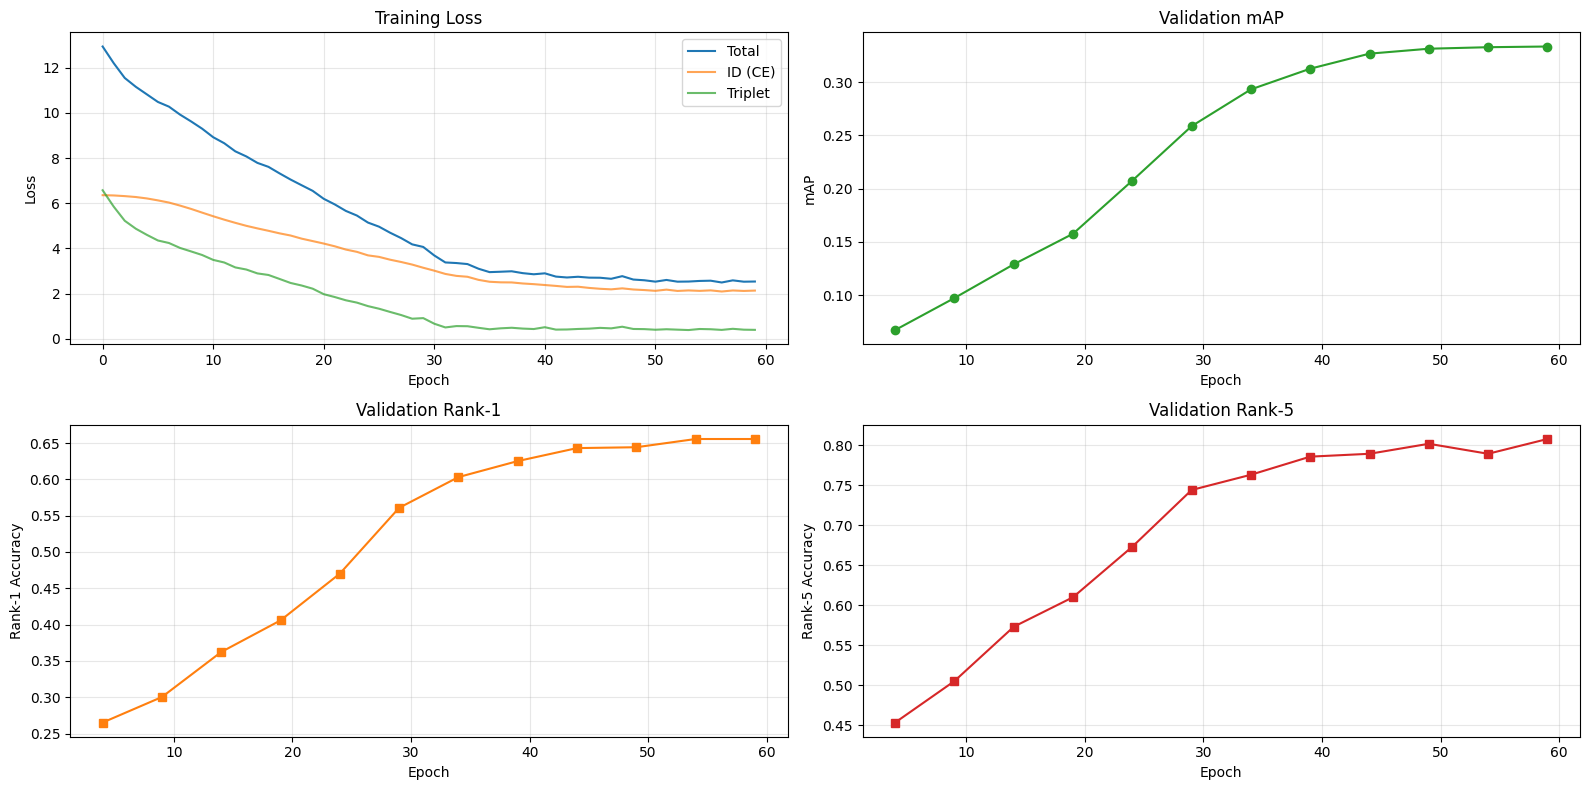

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Loss curves
axes[0, 0].plot(history['loss'], label='Total')
axes[0, 0].plot(history['loss_id'], label='ID (CE)', alpha=0.7)
axes[0, 0].plot(history['loss_trip'], label='Triplet', alpha=0.7)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# mAP
eval_epochs = list(range(EVAL_EVERY-1, len(history['loss']), EVAL_EVERY))
if len(eval_epochs) > len(history['mAP']):
    eval_epochs = eval_epochs[:len(history['mAP'])]
axes[0, 1].plot(eval_epochs, history['mAP'], 'o-', color='tab:green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('mAP')
axes[0, 1].set_title('Validation mAP')
axes[0, 1].grid(True, alpha=0.3)

# Rank-1
axes[1, 0].plot(eval_epochs, history['rank1'], 's-', color='tab:orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Rank-1 Accuracy')
axes[1, 0].set_title('Validation Rank-1')
axes[1, 0].grid(True, alpha=0.3)

# Rank-5
axes[1, 1].plot(eval_epochs, history['rank5'], 's-', color='tab:red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Rank-5 Accuracy')
axes[1, 1].set_title('Validation Rank-5')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)

<Figure size 640x480 with 0 Axes>